# Week1_ex2 Mesh Verification - Independent Mesh per Sweep Point

The original Week1_ex2 sweep uses `CopyMesh: True` and `SolveWithCopiedMeshOnly: True`, so every point in the c1 sweep reuses the adaptive mesh generated at the nominal 100A setup. This notebook rebuilds the same model but turns those options off, forcing AEDT to run a fresh adaptive mesh at every sweep point. If the kink around 100A disappears here, mesh reuse was the cause. If it stays, the kink is a real physical effect.

In [1]:
import pandas as pd
import numpy as np
import os
import ansys.aedt.core
import math
import shutil
import time

In [2]:
# 1. Launch AEDT
DT = ansys.aedt.core.Desktop(version="2025.2", non_graphical=False, student_version=True)

# 2. Turn off autosave
DT.disable_autosave()

# 3. Create project and set solution type
sol_type = "Magnetostatic"
M3D = ansys.aedt.core.maxwell.Maxwell3d(solution_type=sol_type)

# 4. odesign object for script-recording style calls
oDesign = M3D.odesign

PyAEDT INFO: Python version 3.12.13 | packaged by Anaconda, Inc. | (main, Jul  9 2026, 14:26:47) [MSC v.1942 64 bit (AMD64)].
PyAEDT INFO: PyAEDT version 0.15.3.
PyAEDT INFO: Initializing new Desktop session.
PyAEDT INFO: Log on console is enabled.
PyAEDT INFO: Log on file C:\Users\abane\AppData\Local\Temp\pyaedt_abane_435daef3-ebbf-4ce4-bb8e-b00b4cd2e293.log is enabled.
PyAEDT INFO: Log on AEDT is disabled.
PyAEDT INFO: Debug logger is disabled. PyAEDT methods will not be logged.
PyAEDT INFO: Launching PyAEDT with gRPC plugin.
PyAEDT INFO: New AEDT session is starting on gRPC port 52674.
PyAEDT INFO: Electronics Desktop started on gRPC port: 52674 after 75.52883195877075 seconds.
PyAEDT INFO: AEDT installation Path C:\Program Files\ANSYS Inc\ANSYS Student\v252\AnsysEM
PyAEDT INFO: Ansoft.ElectronicsDesktop.2025.2 Student version started with process ID 67172.
PyAEDT INFO: Python version 3.12.13 | packaged by Anaconda, Inc. | (main, Jul  9 2026, 14:26:47) [MSC v.1942 64 bit (AMD64)].
P

In [3]:
## Set up output directory for results ##

# Project name kept separate from the original Week1_ex2 project on purpose,
# so this run never overwrites the original mesh-reuse results
proj_name = "Week1_ex2_mesh_verification"

base_dir = os.environ.get("ANSYS_PROJECT_DIR", os.getcwd())
dir = os.path.join(base_dir, proj_name)
print(dir)

os.makedirs(dir, exist_ok=True)

desi_name = "Week1_ex2_mesh_verification"


C:\Users\abane\ansys\practice\Week1_ex2_mesh_verification


In [4]:
## Save project and apply design name ##

proj = M3D.oproject
proj.SaveAs(f"{dir}\\{proj_name}.aedt", True)
M3D.rename_design(desi_name, save=False)
M3D.save_project()

PyAEDT INFO: Project Week1_ex2_mesh_verification Saved correctly


True

In [5]:
## Create geometry ##
# Identical to Week1_ex2 - the model itself is not the variable being tested here

origin = [0, 0, -5]
sizes = [10, -30, 10]
box1 = M3D.modeler.create_box(origin=origin, sizes=sizes, name=None, material=None)

vector = [30, 0, 0]
M3D.modeler.duplicate_along_line(assignment=box1, vector=vector, clones=2, attach=False, is_3d_comp=False, duplicate_assignment=True)
box2 = M3D.modeler.object_list[-1]

origin = [0, -30, -5]
sizes = [50, -10, 10]
box3 = M3D.modeler.create_box(origin=origin, sizes=sizes, name=None, material=None)

core = M3D.modeler.unite(assignment=[box1, box2, box3], purge=False, keep_originals=False)
core = M3D.modeler.get_object_from_name(assignment=core)

origin = [0, 0, 0]
vector = [0, 1, 0]
M3D.modeler.duplicate_and_mirror(assignment=core, origin=origin, vector=vector, is_3d_comp=False, duplicate_assignment=True)
core_tmp = M3D.modeler.object_list[-1]

M3D.modeler.unite(assignment=[core, core_tmp], purge=False, keep_originals=False)

M3D.assign_material(assignment=core, material="steel_1008")
core.name = "Core"

origin = [51, -40, -5]
sizes = [10, 80, 10]
bar = M3D.modeler.create_box(origin=origin, sizes=sizes, name="Bar", material="steel_1008")

origin = [45, 30, 10]
sizes = [-20, -60, -20]
coil = M3D.modeler.create_box(origin=origin, sizes=sizes, name="Coil", material="copper")
coil.subtract(tool_list=core, keep_originals=True)

origin = [0, -10, -5]
sizes = [10, 20, 10]
magnet = M3D.modeler.create_box(origin=origin, sizes=sizes, name="Magnet", material="NdFe35")
core.subtract(tool_list=magnet, keep_originals=True)

PyAEDT INFO: Modeler class has been initialized! Elapsed time: 0m 0sec
PyAEDT INFO: Materials class has been initialized! Elapsed time: 0m 0sec


c:\Users\abane\anaconda\envs\pyaedt_env\Lib\site-packages\ansys\aedt\core\visualization\advanced\misc.py:43: UserWarning: The PyVista module is required to run functionalities of ansys.aedt.core.visualization.advanced.misc.
Install with 

pip install pyvista
  warnings.warn(


PyAEDT INFO: Parsing design objects. This operation can take time
PyAEDT INFO: Refreshing bodies from Object Info
PyAEDT INFO: Bodies Info Refreshed Elapsed time: 0m 0sec
PyAEDT INFO: 3D Modeler objects parsed. Elapsed time: 0m 0sec
PyAEDT INFO: Union of 3 objects has been executed.
PyAEDT INFO: Parsing design objects. This operation can take time
PyAEDT INFO: Refreshing bodies from Object Info
PyAEDT INFO: Bodies Info Refreshed Elapsed time: 0m 0sec
PyAEDT INFO: 3D Modeler objects parsed. Elapsed time: 0m 0sec
PyAEDT INFO: Union of 2 objects has been executed.


In [6]:
## Set magnet polarization direction ##

origin = magnet.faces[0].center
M3D.modeler.create_coordinate_system(origin=origin, reference_cs='Global', name="FaceCS1", mode='axis', view='iso', x_pointing=None, y_pointing=None, psi=0, theta=0, phi=0, u=None)

magnet.part_coordinate_system = "FaceCS1"
M3D.modeler.set_working_coordinate_system("Global")

NdFe35 = M3D.materials.exists_material(material="NdFe35")
NdFe35.set_magnetic_coercivity('-890000', x=0, y=1, z=0)

True

In [7]:
## Assign insulating boundary to the coil ##

coil_boundary = M3D.assign_insulating(assignment=coil, insulation=None)

PyAEDT INFO: Boundary Insulating Insulation_B6ZJ59 has been created.


In [8]:
## Apply current excitation to the coil ##

M3D.modeler.section(assignment=coil, plane="XY", create_new=True, section_cross_object=False)
coil_section = M3D.modeler.sheet_objects[-1]

coil_terminal = M3D.modeler.separate_bodies(assignment=coil_section, create_group=False)
M3D.modeler.delete(assignment=(M3D.modeler.sheet_objects[-1]))
coil_terminal[0].name = "Coil_Terminal"

M3D["c1"] = "100A"
current1 = M3D.assign_current(assignment=coil_terminal, amplitude="c1", phase='0deg', solid=False, swap_direction=False, name="Current1")

PyAEDT INFO: Parsing design objects. This operation can take time
PyAEDT INFO: Refreshing bodies from Object Info
PyAEDT INFO: Bodies Info Refreshed Elapsed time: 0m 0sec
PyAEDT INFO: 3D Modeler objects parsed. Elapsed time: 0m 0sec
PyAEDT INFO: Deleted 1 Objects: Coil_Section1_Separate1.
PyAEDT INFO: Boundary Current Current1 has been created.


In [9]:
## Assign virtual force boundary condition to the bar ##

M3D.assign_force(assignment=bar, coordinate_system='Global', is_virtual=True, force_name="Force1")

PyAEDT INFO: Boundary Force Force1 has been created.


In [10]:
## Create simulation region ##

region = M3D.modeler.create_region(pad_value=50, pad_type='Percentage Offset', name='Region')

In [11]:
## Create and inspect analysis setup ##

my_setup = M3D.create_setup(name="Setup1")

# 5. Raise MaximumPasses a bit higher than the original (10 -> 15) so each
# independently-meshed point still gets a fair chance to converge on its own
my_setup.props['MaximumPasses'] = 15

In [12]:
# Run the nominal analysis

my_setup.analyze()

PyAEDT INFO: Key Desktop/ActiveDSOConfigurations/Maxwell 3D correctly changed.
PyAEDT INFO: Solving design setup Setup1
PyAEDT INFO: Design setup Setup1 solved correctly in 0.0h 0.0m 15.0s


In [13]:
## Set up parametric sweep of coil current ##

param_Setups = M3D.parametrics
c1_param = param_Setups.add(variable="c1", start_point="0A", end_point="500A", step="100A", variation_type='LinearStep', solution=None, name="c1_param")

PyAEDT INFO: Parsing C:/Users/abane/ansys/practice/Week1_ex2_mesh_verification/Week1_ex2_mesh_verification.aedt.
PyAEDT INFO: File C:/Users/abane/ansys/practice/Week1_ex2_mesh_verification/Week1_ex2_mesh_verification.aedt correctly loaded. Elapsed time: 0m 0sec
PyAEDT INFO: aedt file load time 0.07664847373962402


In [14]:
# 6. Turn mesh reuse OFF - this is the one setting that differs from the
# original Week1_ex2 notebook. Every sweep point now runs its own adaptive
# mesh pass instead of copying the mesh from the nominal 100A setup
c1_param.props['ProdOptiSetupDataV2'] = {'SaveFields': True,
                                            'CopyMesh': False,
                                            'SolveWithCopiedMeshOnly': False}
c1_param.update()
c1_param.props

{'IsEnabled': True,
 'ProdOptiSetupDataV2': {'SaveFields': True,
  'CopyMesh': False,
  'SolveWithCopiedMeshOnly': False},
 'StartingPoint': {},
 'Sim. Setups': ['Setup1'],
 'Sweeps': {'SweepDefinition': {'Variable': 'c1',
   'Data': 'LIN 0A 500A 100A',
   'OffsetF1': False,
   'Synchronize': 0}},
 'Sweep Operations': {},
 'Goals': {}}

In [15]:
# Run the parametric sweep
# This will take noticeably longer than the original run since AEDT meshes
# each of the 6 points independently instead of reusing one mesh

c1_param.analyze()

PyAEDT INFO: Key Desktop/ActiveDSOConfigurations/Maxwell 3D correctly changed.
PyAEDT INFO: Solving Optimetrics
PyAEDT INFO: Key Desktop/ActiveDSOConfigurations/Maxwell 3D correctly changed.
PyAEDT INFO: Design setup c1_param solved correctly in 0.0h 1.0m 13.0s


True

In [16]:
# Save final results

M3D.save_project()

PyAEDT INFO: Project Week1_ex2_mesh_verification Saved correctly


True

## Compare against the original mesh-reuse result

The values below for the original run are copied from `Week1_ex2_analysis.ipynb` (Force1.Force_x, `CopyMesh: True`), so the comparison does not depend on having that project open at the same time.

In [17]:
# 7. Pull the independent-mesh sweep results from this project
sweep_data = M3D.post.get_solution_data(
    expressions=["Force1.Force_x"],
    variations={"c1": ["All"]},
    primary_sweep_variable="c1"
)

c1_list = sweep_data.primary_sweep_values
force_independent = sweep_data.data_real("Force1.Force_x")

for c, f in zip(c1_list, force_independent):
    print(c, f)

c:\Users\abane\anaconda\envs\pyaedt_env\Lib\site-packages\ansys\aedt\core\visualization\plot\pyvista.py:53: UserWarning: The PyVista module is required to run some functionalities of PostProcess.
Install with 

pip install pyvista
  warnings.warn(


PyAEDT INFO: Parsing C:/Users/abane/ansys/practice/Week1_ex2_mesh_verification/Week1_ex2_mesh_verification.aedt.
PyAEDT INFO: File C:/Users/abane/ansys/practice/Week1_ex2_mesh_verification/Week1_ex2_mesh_verification.aedt correctly loaded. Elapsed time: 0m 0sec
PyAEDT INFO: aedt file load time 0.047533273696899414
PyAEDT INFO: PostProcessor class has been initialized! Elapsed time: 0m 0sec
PyAEDT INFO: Post class has been initialized! Elapsed time: 0m 0sec
PyAEDT INFO: Solution Data Correctly Loaded.
0A -0.0553583066632242
100A -0.125270452998183
200A -0.569055927241205
300A -1.10896287384087
400A -1.70033548472145
500A -2.1328777164279


In [18]:
# 8. Compare deltas per 100A step against the original mesh-reuse run
force_original = [-0.0553583066632242, -0.157547201833921, -0.741917980286765,
                   -1.35474735476014, -1.91523601946461, -2.53987110885668]

print("c1        original(reuse)   independent-mesh")
for c, fo, fi in zip(c1_list, force_original, force_independent):
    print(f"{c:>6}  {fo:>16.5f}  {fi:>16.5f}")

print("\nDelta per 100A step:")
for i in range(len(force_original) - 1):
    do = force_original[i + 1] - force_original[i]
    di = force_independent[i + 1] - force_independent[i]
    print(f"{c1_list[i]} -> {c1_list[i+1]}: original={do:.5f}  independent={di:.5f}")

c1        original(reuse)   independent-mesh
   0.0          -0.05536          -0.05536
 100.0          -0.15755          -0.12527
 200.0          -0.74192          -0.56906
 300.0          -1.35475          -1.10896
 400.0          -1.91524          -1.70034
 500.0          -2.53987          -2.13288

Delta per 100A step:
0A -> 100A: original=-0.10219  independent=-0.06991
100A -> 200A: original=-0.58437  independent=-0.44379
200A -> 300A: original=-0.61283  independent=-0.53991
300A -> 400A: original=-0.56049  independent=-0.59137
400A -> 500A: original=-0.62464  independent=-0.43254


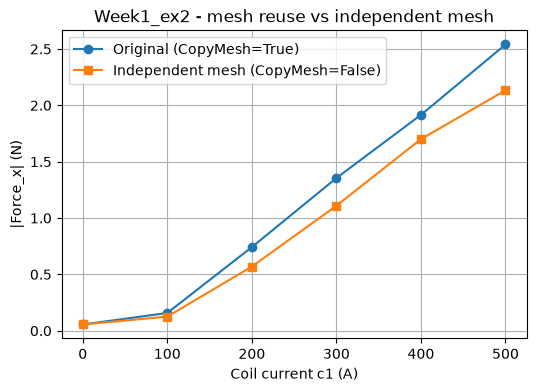

In [19]:
# 9. Plot both curves together
import matplotlib.pyplot as plt

c1_numeric = [float(str(c).replace("A", "")) for c in c1_list]

plt.figure(figsize=(6, 4))
plt.plot(c1_numeric, [abs(f) for f in force_original], marker="o", label="Original (CopyMesh=True)")
plt.plot(c1_numeric, [abs(f) for f in force_independent], marker="s", label="Independent mesh (CopyMesh=False)")
plt.xlabel("Coil current c1 (A)")
plt.ylabel("|Force_x| (N)")
plt.title("Week1_ex2 - mesh reuse vs independent mesh")
plt.legend()
plt.grid(True)
plt.savefig("Week1_ex2_mesh_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Findings

- If the two curves overlap closely and both show the same slowdown between 0A and 100A, mesh reuse is not the cause of the kink - the effect is physical, most likely tied to how much of the magnet's bias flux actually reaches the Bar at low current versus higher current.
- If the independent-mesh curve is noticeably smoother through 0-100A, mesh reuse was inflating the apparent kink, and the nominal-100A mesh was undersized for the 0A field distribution.